In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

### 1. Retrieve Data

Retrieve data from 12 stocks before narrowing it to the chosen 5.

In [2]:
# specify the symbols to read
tickers = [
    "AAPL",  # Tech
    "META",  # Tech
    "NVDA",  # Semiconductors
    "SPY",   # S&P 500 ETF
    "TSLA",  # Consumer Goods
]

# specify the time period - 2020 to 2024
start_date = "2020-01-01"
end_date = "2024-12-31"

# download the stock price data
stocks_df = yf.download(tickers, start=start_date, end=end_date)

[*********************100%***********************]  5 of 5 completed


In [3]:
stocks_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1257 non-null   float64
 1   (Close, META)   1257 non-null   float64
 2   (Close, NVDA)   1257 non-null   float64
 3   (Close, SPY)    1257 non-null   float64
 4   (Close, TSLA)   1257 non-null   float64
 5   (High, AAPL)    1257 non-null   float64
 6   (High, META)    1257 non-null   float64
 7   (High, NVDA)    1257 non-null   float64
 8   (High, SPY)     1257 non-null   float64
 9   (High, TSLA)    1257 non-null   float64
 10  (Low, AAPL)     1257 non-null   float64
 11  (Low, META)     1257 non-null   float64
 12  (Low, NVDA)     1257 non-null   float64
 13  (Low, SPY)      1257 non-null   float64
 14  (Low, TSLA)     1257 non-null   float64
 15  (Open, AAPL)    1257 non-null   float64
 16  (Open, META)    1257 non-null   float64
 17  (Open, NVDA)   

In [4]:
prices_df = stocks_df["High"]
prices_df.head()

Ticker,AAPL,META,NVDA,SPY,TSLA
Date,,,,,
2020-01-02,72.528574,208.334724,5.971076,297.717289,28.713333
2020-01-03,72.523769,208.940499,5.919309,296.571717,30.266666
2020-01-06,72.374162,211.303958,5.905370,296.654338,30.104000
2020-01-07,72.600952,213.091491,6.017371,296.480259,31.441999
2020-01-08,73.455103,214.739979,6.024091,298.532930,33.232666


In [5]:
prices_df = stocks_df["Low"]
prices_df.head()

Ticker,AAPL,META,NVDA,SPY,TSLA
Date,,,,,
2020-01-02,71.223252,204.839152,5.891681,295.554657,28.114000
2020-01-03,71.539352,205.514434,5.826473,294.244147,29.128000
2020-01-06,70.634539,205.087388,5.756038,293.566170,29.333332
2020-01-07,71.775781,210.281121,5.883469,295.288969,30.224001
2020-01-08,71.698589,211.135155,5.927274,295.683052,31.215334


In [6]:
prices_df = stocks_df["Open"]
prices_df.head()

Ticker,AAPL,META,NVDA,SPY,TSLA
Date,,,,,
2020-01-02,71.476592,205.315818,5.942205,296.480193,28.299999
2020-01-03,71.696183,205.772640,5.851362,294.299126,29.366667
2020-01-06,70.885472,205.266132,5.782171,293.685302,29.364668
2020-01-07,72.345197,211.343706,5.928518,296.003732,30.760000
2020-01-08,71.698589,211.522449,5.967345,295.930460,31.580000


In [7]:
prices_df = stocks_df["Close"]
prices_df.head()

Ticker,AAPL,META,NVDA,SPY,TSLA
Date,,,,,
2020-01-02,72.468254,208.324799,5.971076,297.698944,28.684000
2020-01-03,71.763741,207.222504,5.875504,295.444580,29.534000
2020-01-06,72.335556,211.125214,5.900144,296.571869,30.102667
2020-01-07,71.995346,211.582031,5.971576,295.738007,31.270666
2020-01-08,73.153503,213.727051,5.982776,297.314178,32.809334


In [8]:
# Check for missing values
missing_values = prices_df.isnull().sum()
missing_values

Ticker
AAPL    0
META    0
NVDA    0
SPY     0
TSLA    0
dtype: int64

### 2. Exploratory Data Analysis

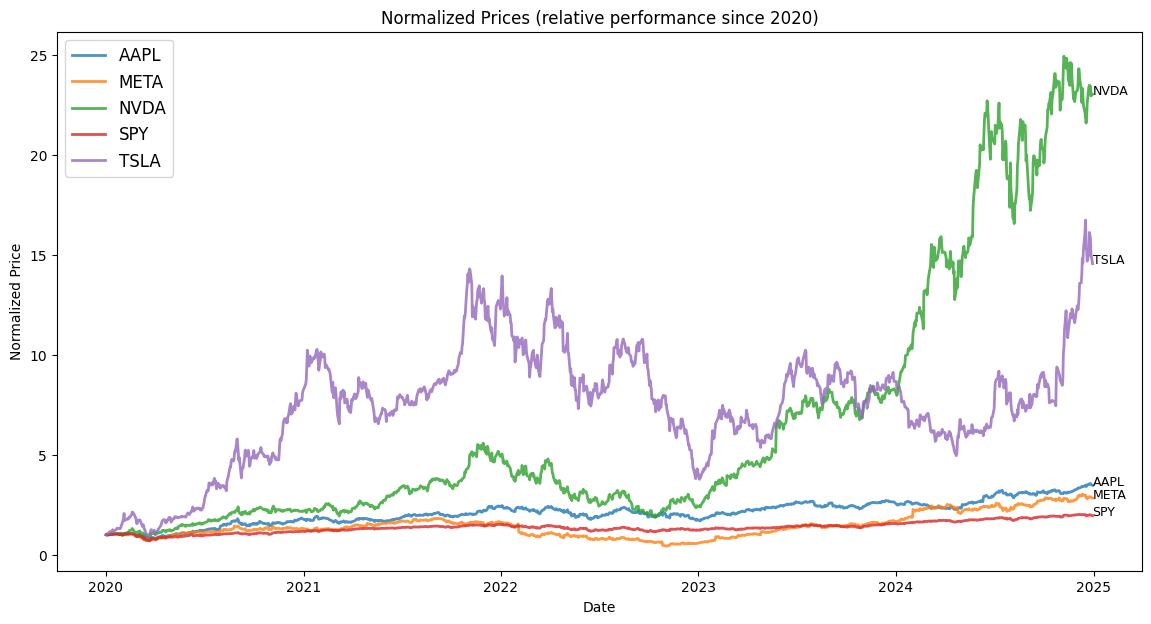

In [9]:
# normalise all stock prices to start at 1
normalised_df = prices_df / prices_df.iloc[0]

plt.figure(figsize=(14, 7))
for c in normalised_df.columns:
    plt.plot(normalised_df.index, normalised_df[c], lw=2, alpha=0.8, label=c)

    # Add label at the last point
    plt.text(
        normalised_df.index[-1],  # last date
        normalised_df[c].iloc[-1],  # last value
        c,  # ticker symbol
        fontsize=9,
    )

plt.legend(loc="upper left", fontsize=12)
plt.title("Normalized Prices (relative performance since 2020)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.show()

We see that NVDA and TSLA are the outliers.

In [10]:
volume_df = stocks_df["Volume"]
avg_volume = volume_df.mean().sort_values(ascending=False)

print("Average daily trading volume:")
print(avg_volume)

Average daily trading volume:
Ticker
NVDA    4.470044e+08
TSLA    1.255755e+08
AAPL    9.061168e+07
SPY     8.167490e+07
META    2.315839e+07
dtype: float64


/var/folders/7x/56svhln929zdh2xhr3mwqg4r0000gn/T/ipykernel_82122/1518659879.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(volatility))


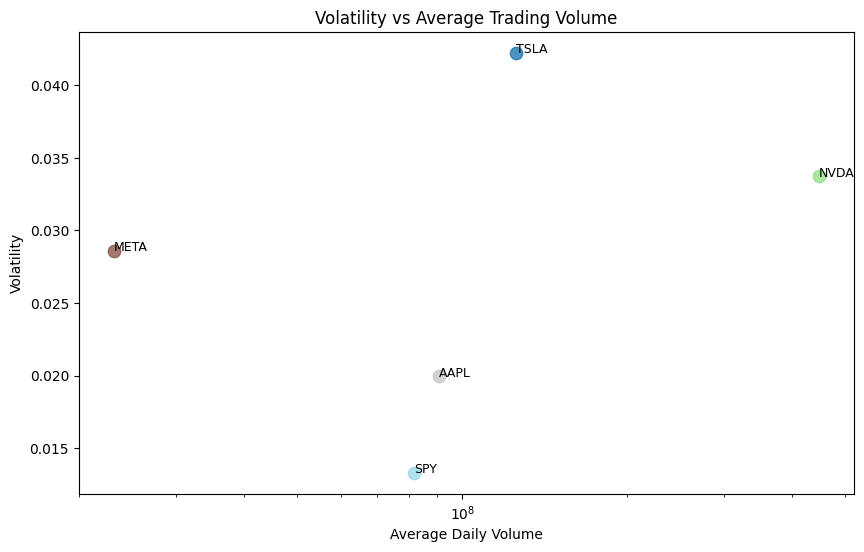

In [11]:
import matplotlib.cm as cm

returns_df = np.log(prices_df / prices_df.shift(1))
volatility = returns_df.std().sort_values(ascending=False)

avg_volume = stocks_df["Volume"].mean()

# Pick a colormap with N distinct colors
colors = cm.get_cmap("tab20", len(volatility))

plt.figure(figsize=(10, 6))
for i, ticker in enumerate(volatility.index):
    plt.scatter(
        avg_volume[ticker],
        volatility[ticker],
        s=80,
        alpha=0.8,
        color=colors(i),
        label=ticker,
    )
    plt.text(avg_volume[ticker], volatility[ticker], ticker, fontsize=9)

plt.title("Volatility vs Average Trading Volume")
plt.xlabel("Average Daily Volume")
plt.ylabel("Volatility")
plt.xscale("log")  # because volumes vary a lot
plt.show()

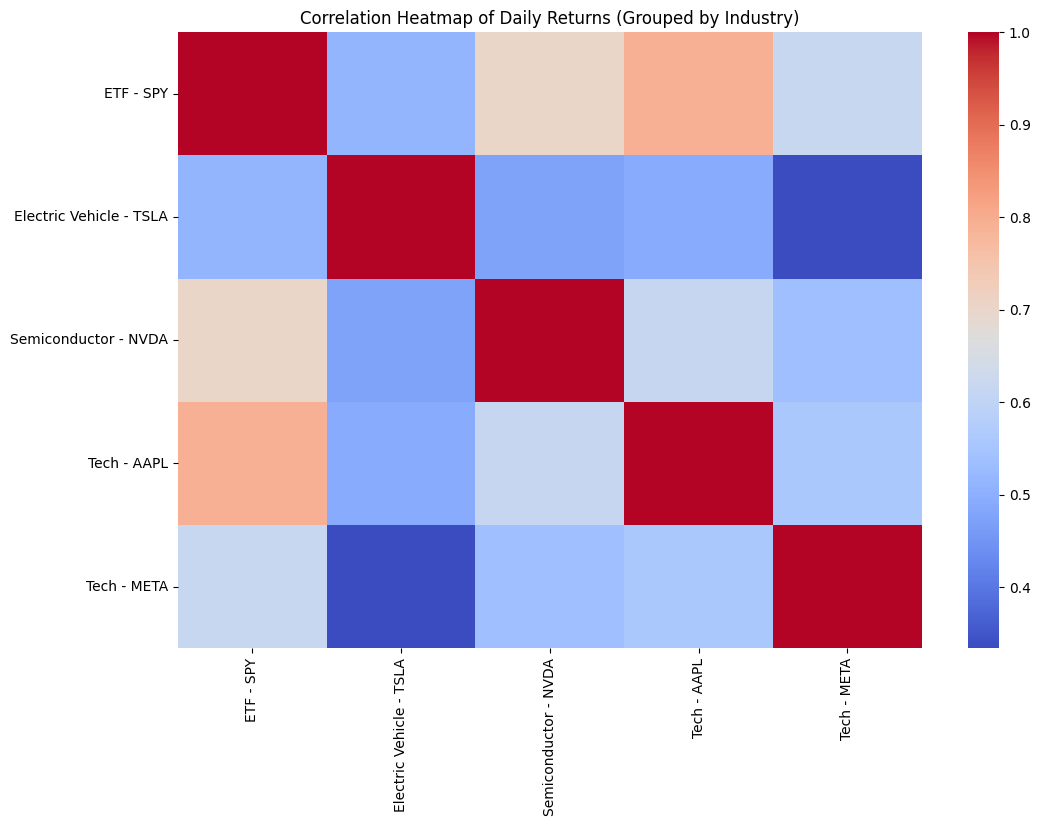

In [12]:
# Correlation matrix of returns
industry_map = {
    "SPY": "ETF",
    "AAPL": "Tech",
    "META": "Tech",
    "NVDA": "Semiconductor",
    "TSLA": "Electric Vehicle",
}

# Compute correlation matrix
corr_matrix = returns_df.corr()

# Sort tickers by industry, then rename with industry prefix
sorted_tickers = sorted(corr_matrix.columns, key=lambda t: industry_map[t])
corr_matrix = corr_matrix.loc[sorted_tickers, sorted_tickers]
corr_matrix.columns = [f"{industry_map[t]} - {t}" for t in corr_matrix.columns]
corr_matrix.index = corr_matrix.columns

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Daily Returns (Grouped by Industry)")
plt.show()